<div align="center">
<h1>Boxplot</h1>
</div>
Un boxplot o diagrama de caja es una representación gráfica que demuestra la distribución de un conjunto de datos a través de sus cuartiles, que son medidas para conocer la posición de un valor entre medio de muchos otros. Las líneas que sobresalen de las cajas se conocen como whiskers o bigotes, y determinan la variabilidad fuera de los cuartiles.

In [1]:
import pandas as pd
from plotnine import*
from plotnine.data import *

In [2]:
data=pd.read_excel(r"C:\Users\Easy Data\Dropbox\PC\Documents\Lenguajes para analisis de datos II\Materiales\bar.xlsx")

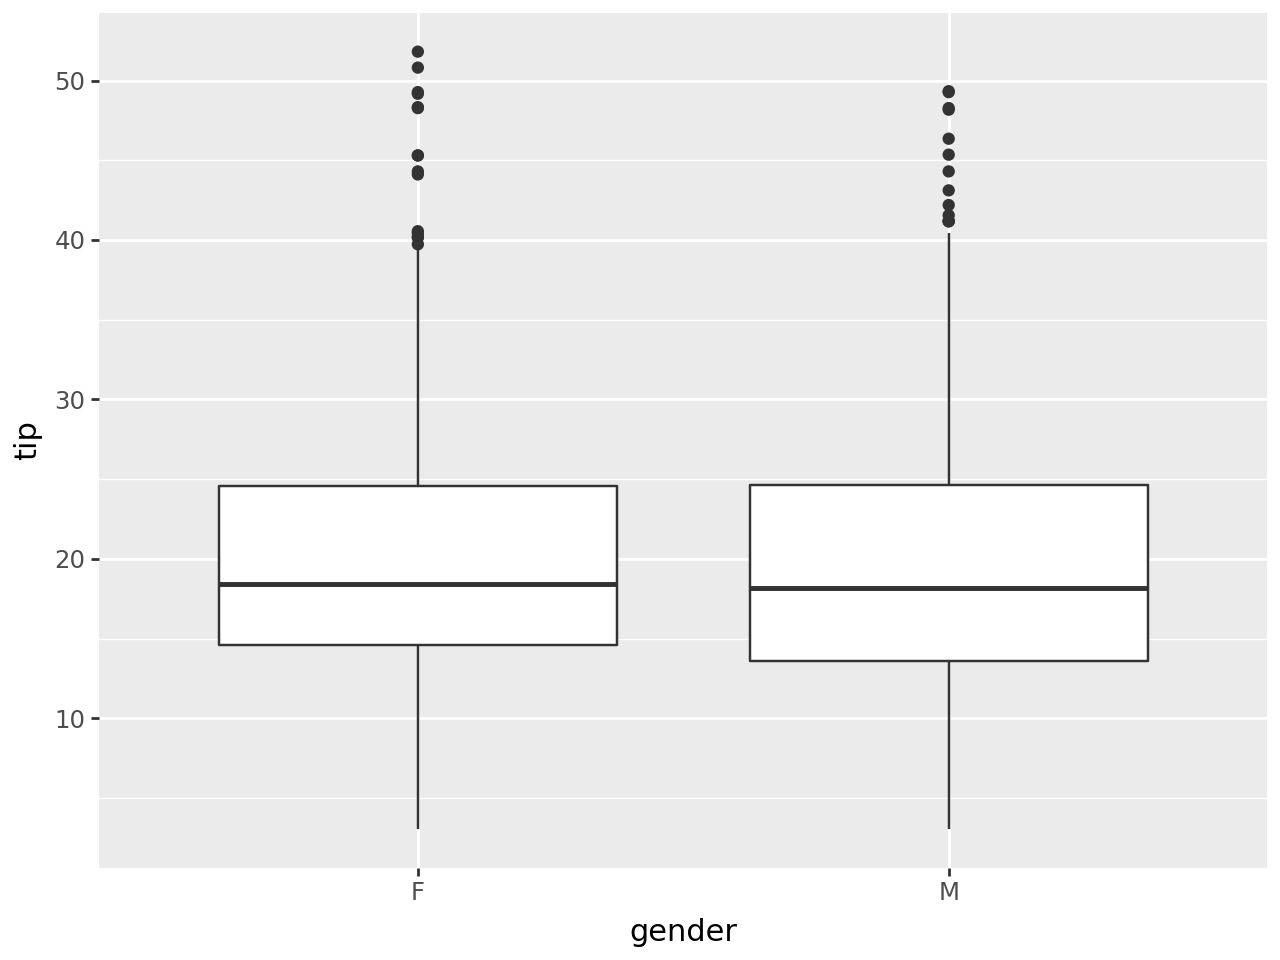

In [3]:
ggplot(aes("gender", "tip"),data)+geom_boxplot()

Para hacerlo más atractivo, usamos fill para elegir el color de la caja, outlier.color para los datos outlier y alpha para definir la transparencia del color que hemos determinando para la caja.

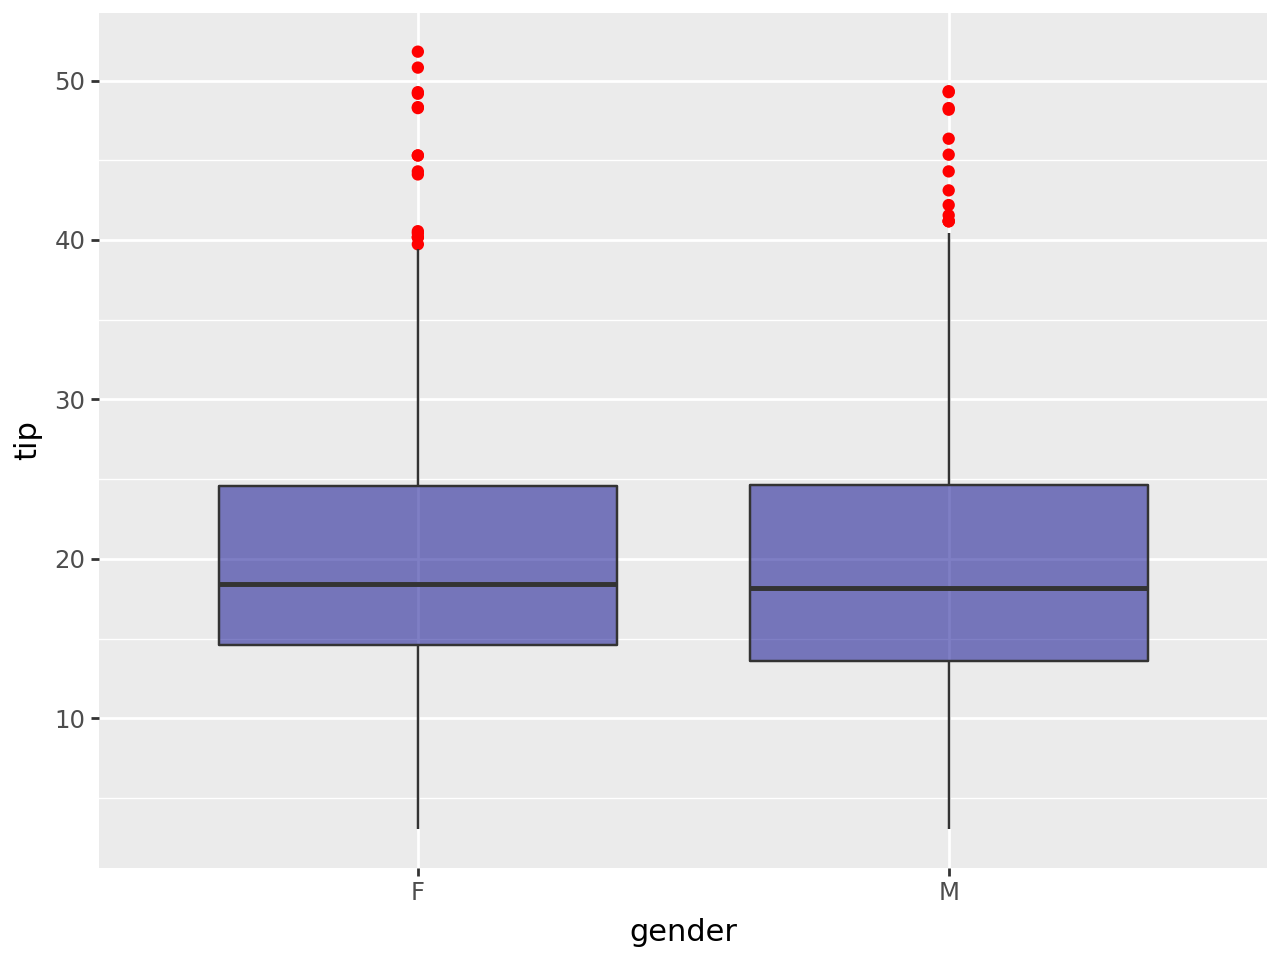

In [4]:
ggplot(aes("gender", "tip"),data) +\
geom_boxplot(fill="darkblue",outlier_color = "red", alpha = 0.5)

Añadimos el título con ggtitle, el nombre del eje x con xlab() y ponemos el gráfico en modo horizontal con coord_flip().

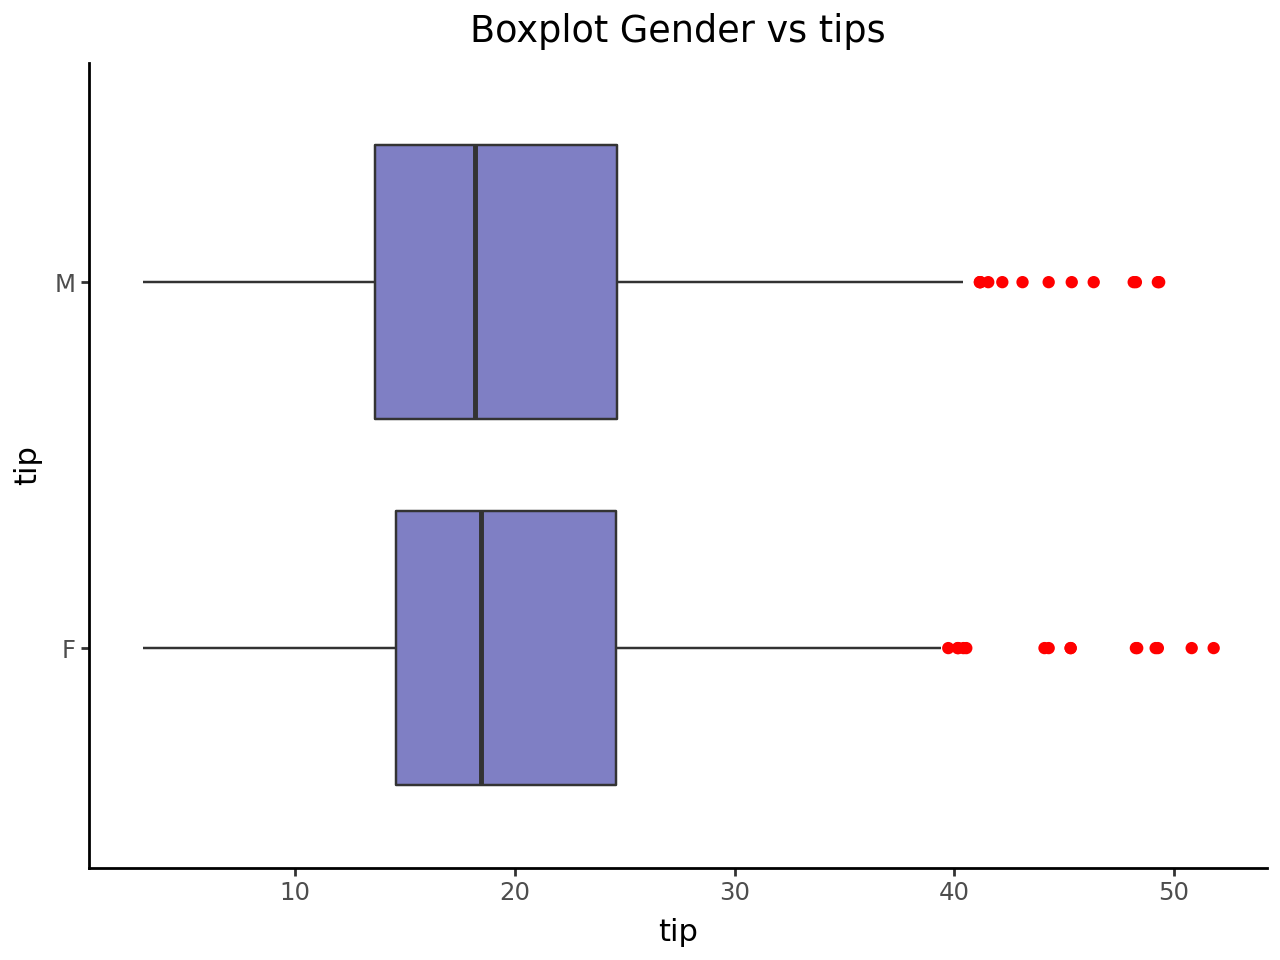

In [5]:
ggplot(aes("gender", "tip"),data) +\
geom_boxplot(fill="darkblue",outlier_color = "red", alpha = 0.5) +\
ggtitle("Boxplot Gender vs tips") + xlab("tip") +\
coord_flip() +theme_classic()

Si queremos emplear otras paletas de colores y cambiar el tema, podemos usar theme y scale_fill_brewer.

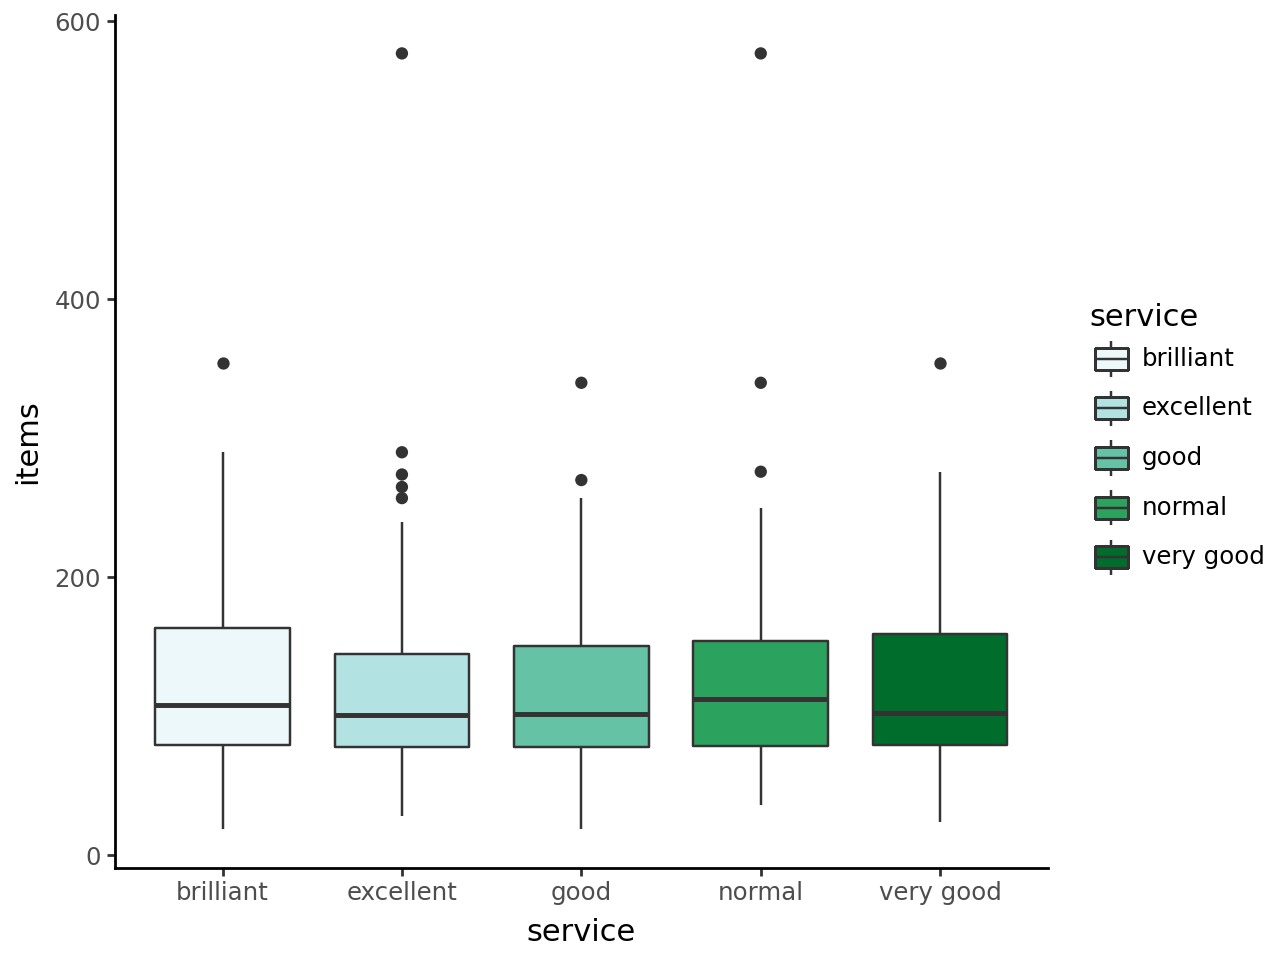

In [6]:
ggplot(aes("service", "items", fill = "service"),data) +\
geom_boxplot()+scale_fill_brewer(type="seq",palette="BuGn") +\
theme_classic()

- Ejercicio 1.

Crea un boxplot donde podamos ver la distribución entre “géneros”, tipo de “servicio” y “propinas”. 

- Ejercicio 2.

Crea un boxplot para analizar la distribución de las "propinas" por "día de la semana" y "tipo de servicio".

- Ejercicio 3.

Crea un boxplot para comparar las "propinas" entre diferentes "años" y "géneros".

- Ejercicio 4.

Analiza la distribución de las "facturas" por "tipo de servicio" y "año".

## Line plots

Un line plot, o gráfico de líneas, es una representación visual de datos en la que las observaciones se muestran a lo largo de un eje de coordenadas cartesianas. Cuando se crea este tipo de gráfico, los puntos de datos individuales se marcan en ambos ejes (X e Y) y se conectan mediante líneas, lo que permite visualizar la relación entre ambos y las tendencias entre los puntos a medida que avanzan a lo largo del eje horizontal. 

 Elegimos los datos que queremos representar del dataset bar.xlsx. Hacemos un groupby() por días de la semana y usamos la función (sum) para sumar todos los valores de las bills.

In [7]:
data2= data.groupby(by="week_day",as_index=False).sum()

Creamos un line plot con los datos elegidos y personalizamos el estilo de la línea con linetype.

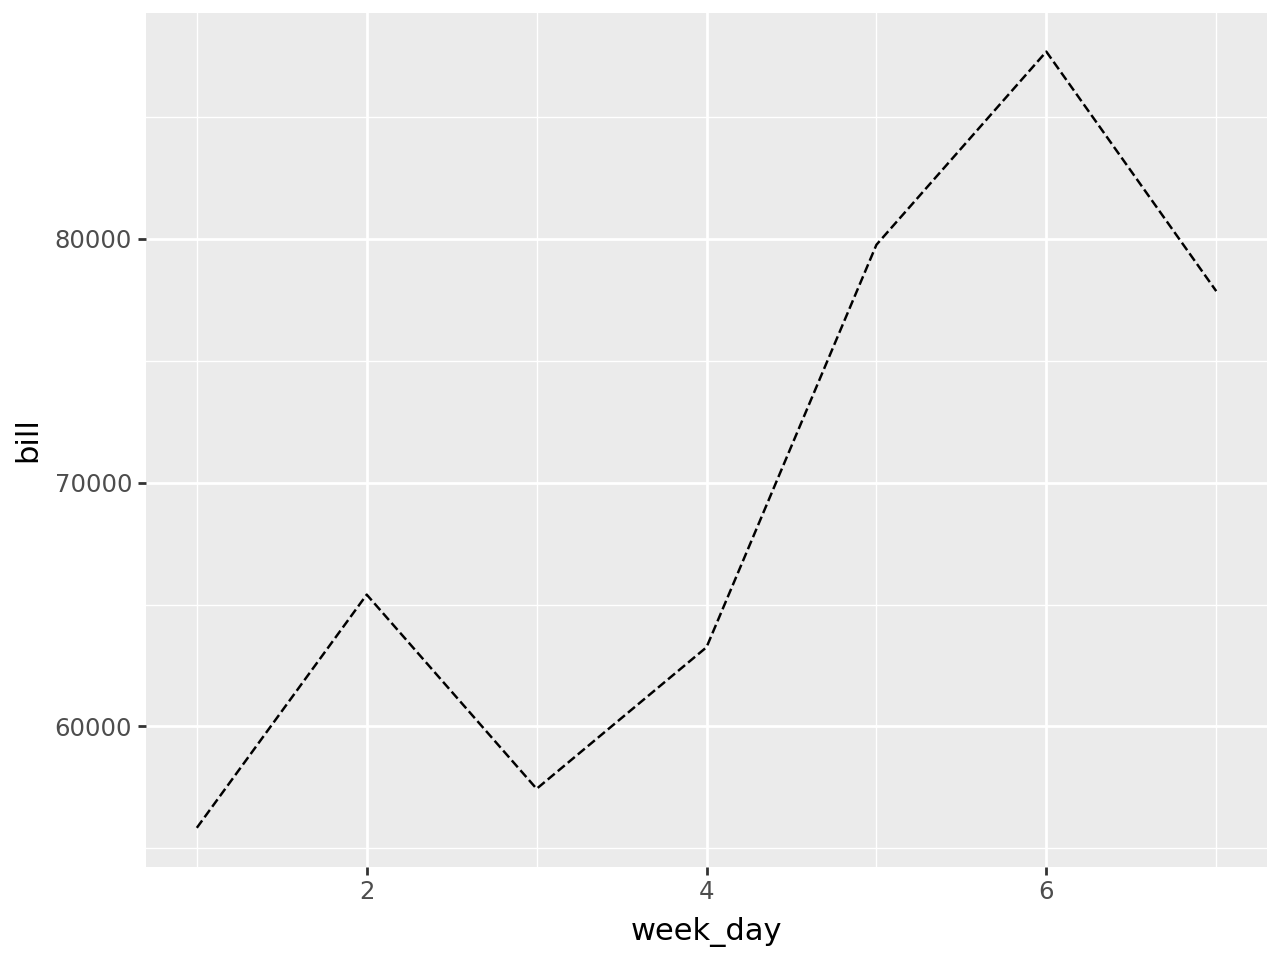

In [8]:
ggplot(aes("week_day", "bill"), data2) + \
geom_line(linetype="dashed")

Podemos personalizar nuestro gráfico de líneas con colores.

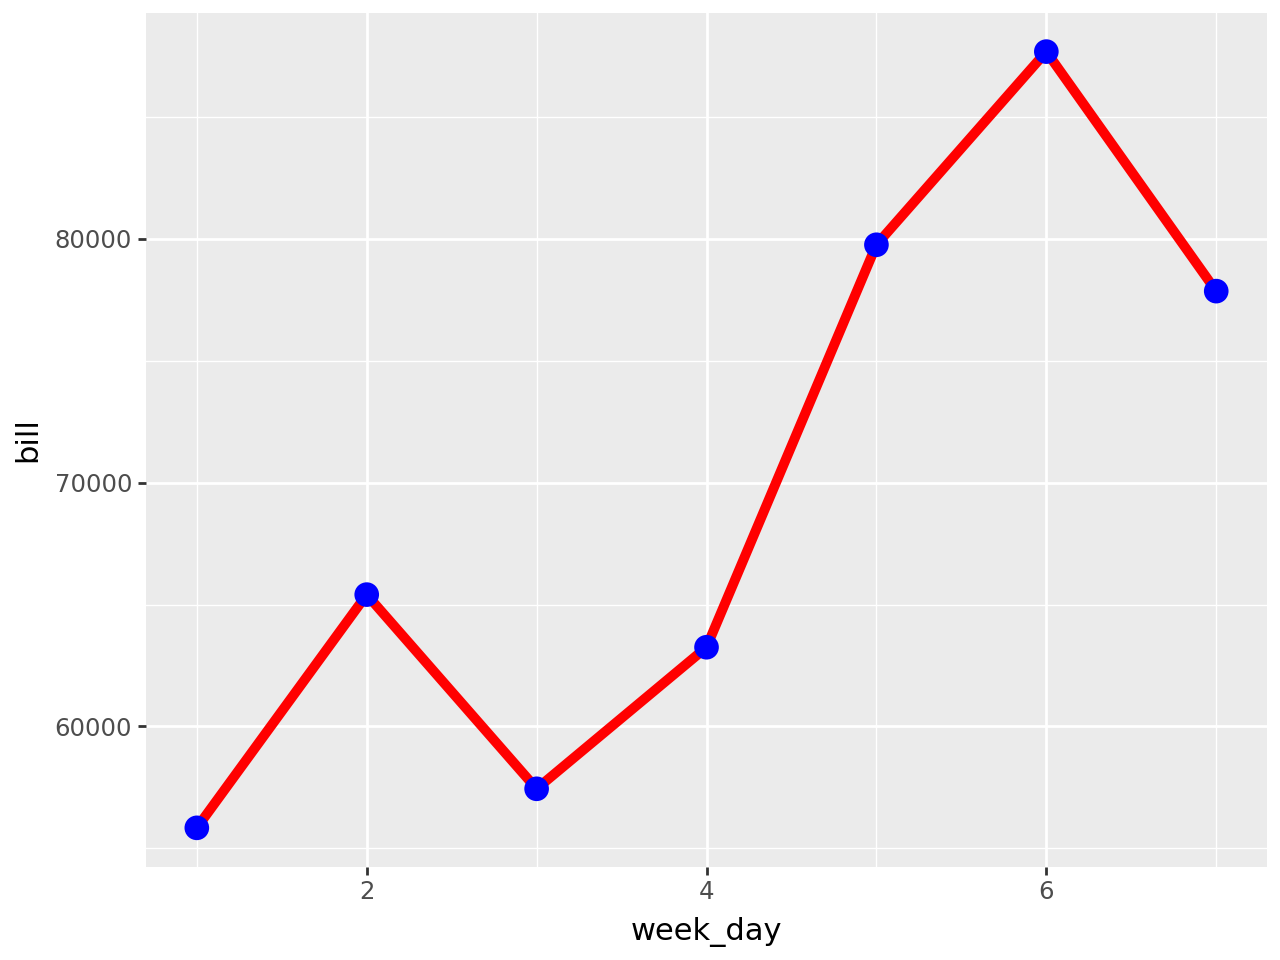

In [15]:
data2= data.groupby(by=["week_day"],as_index=False).sum()

ggplot(aes("week_day", "bill"),data2) + geom_line (size=2,color="red") +\
geom_point(color="blue",size=4)

Si lo preferimos, también podemos cambiar las formas de la línea y de los puntos.

In [17]:
data2= data.groupby(by=["week_day"],as_index=False).sum()

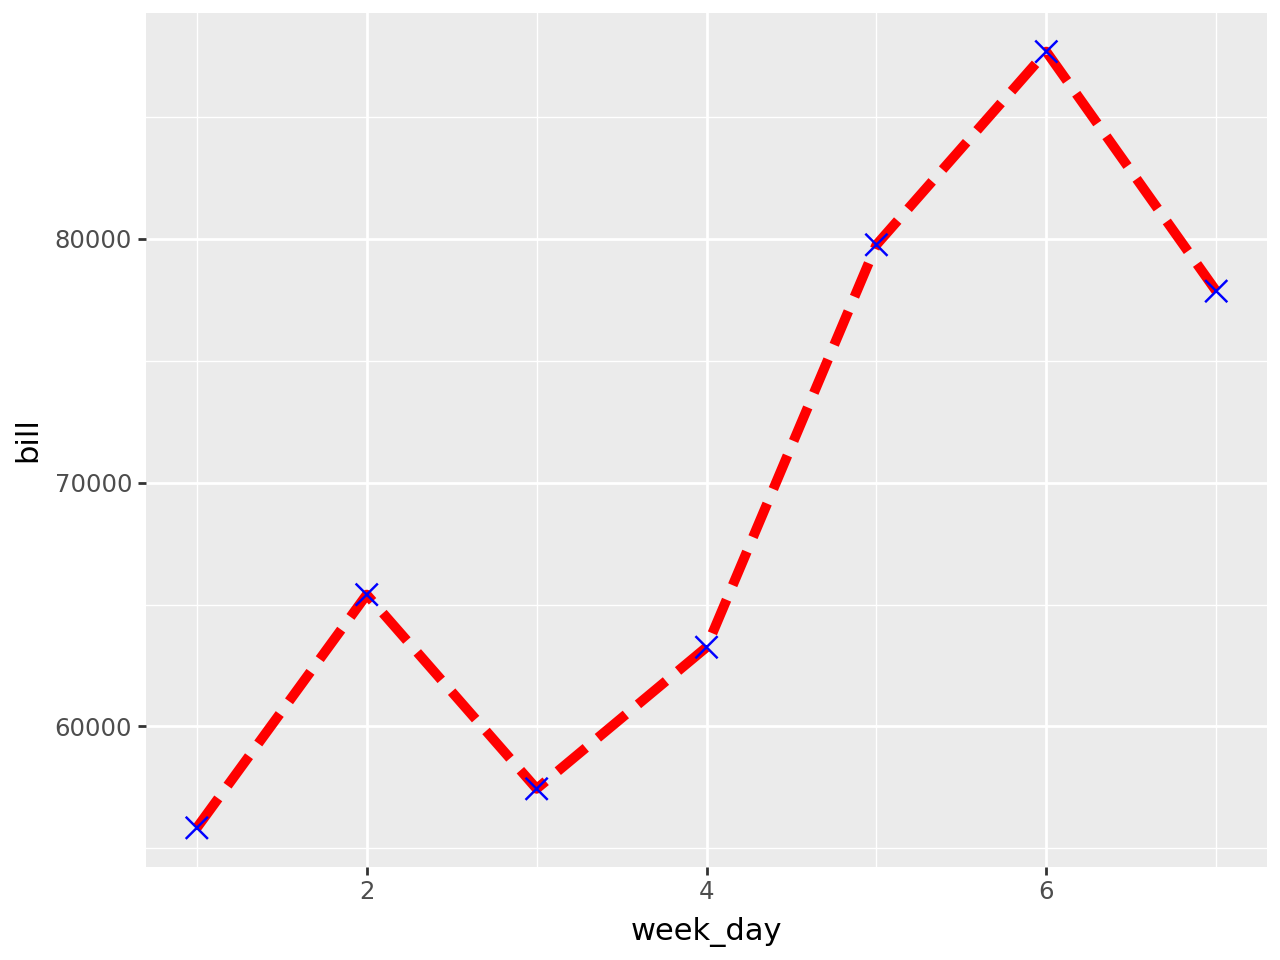

In [20]:
ggplot(aes("week_day", "bill"),data2) +\
geom_line(size=2,color="red",linetype="dashed") +\
geom_point(color="blue",size=4,shape="x")

- Ejercicio 1.
Crea un diagrama de líneas para mostrar el total de películas por "month_added" por 4 nacionalidades (elija cualquier nacionalidad).

- Ejercicio 2.
Siguiendo el diagrama de líneas anterior, agrega los últimos 3 "year_added" (2020,2019,2018).

- Ejercicio 3.
Crea un diagrama de líneas que muestre los pedidos totales por 4 nacionalidades y año y agrega el nombre completo de los meses en el Xlab.

## Correlaciones

In [22]:
data=pd.read_excel(r"C:\Users\Easy Data\Dropbox\PC\Documents\Lenguajes para analisis de datos II\Materiales\bar.xlsx")

Un gráfico de correlación es una representación visual que muestra la relación entre dos variables cuantitativas. Se emplea para identificar y evaluar tanto la fuerza como la dirección de una relación lineal entre las dos variables. Por lo general, son scatterplots a los que se les añade una línea de tendencia o matrices que muestran los coeficientes de correlación.

Ejemplo de creación de un gráfico de correlación
Antes de crear el gráfico en sí mismo, necesitamos dar algunos pasos previos: 

1. Primero usamos el comando corr() para correlacionar todas las variables del dataset bar.xlsx.

In [24]:
correlaciones = data.select_dtypes(include=["float","int"]).corr()

Reseteamos el index.

In [26]:
correlaciones.reset_index(inplace=True)
correlaciones

,level_0,index,day,month,week_day,year,orders,items,bill,tip
0,0,day,1.000000e+00,1.343516e-02,-3.561037e-04,2.772320e-14,-7.787337e-02,-3.760535e-02,-0.058187,0.000903
1,1,month,1.343516e-02,1.000000e+00,4.978166e-03,5.893078e-13,-5.105688e-02,-3.686061e-02,-0.036562,0.010567
2,2,week_day,-3.561037e-04,4.978166e-03,1.000000e+00,3.854762e-15,4.352940e-01,4.077059e-01,0.263021,-0.037553
3,3,year,2.772320e-14,5.893078e-13,3.854762e-15,1.000000e+00,-3.978754e-14,-2.669236e-14,0.004602,0.057779
4,4,orders,-7.787337e-02,-5.105688e-02,4.352940e-01,-3.978754e-14,1.000000e+00,9.100946e-01,0.478364,-0.022806
5,5,items,-3.760535e-02,-3.686061e-02,4.077059e-01,-2.669236e-14,9.100946e-01,1.000000e+00,0.494311,-0.022830
6,6,bill,-5.818697e-02,-3.656221e-02,2.630207e-01,4.601690e-03,4.783642e-01,4.943109e-01,1.000000,-0.006343
7,7,tip,9.034896e-04,1.056724e-02,-3.755277e-02,5.777869e-02,-2.280618e-02,-2.282978e-02,-0.006343,1.000000


Usamos el comando pd.melt().

In [27]:
correlaciones =pd.melt(correlaciones,id_vars=['index'])

Cambiamos de nombre a las columnas.

In [28]:
correlaciones.columns = ["variable1","variable2","correlacion"]  

In [29]:
correlaciones.correlacion = correlaciones.correlacion.round(decimals = 2)  

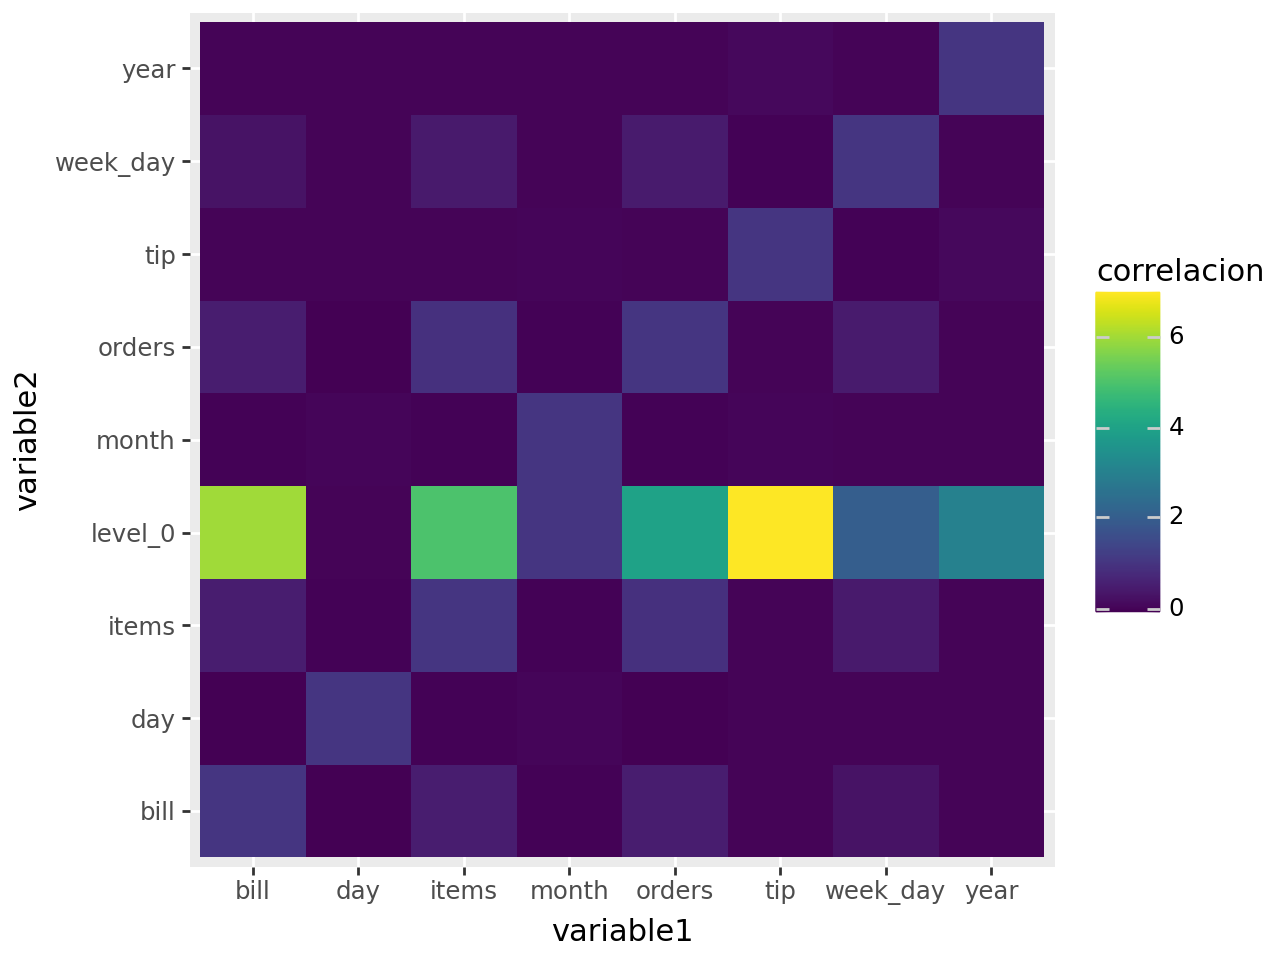

In [ ]:
ggplot(aes(x = "variable1", y = "variable2", fill = "correlacion"),correlaciones) +\
geom_tile()

Cambiamos el color con fill_gradient2()

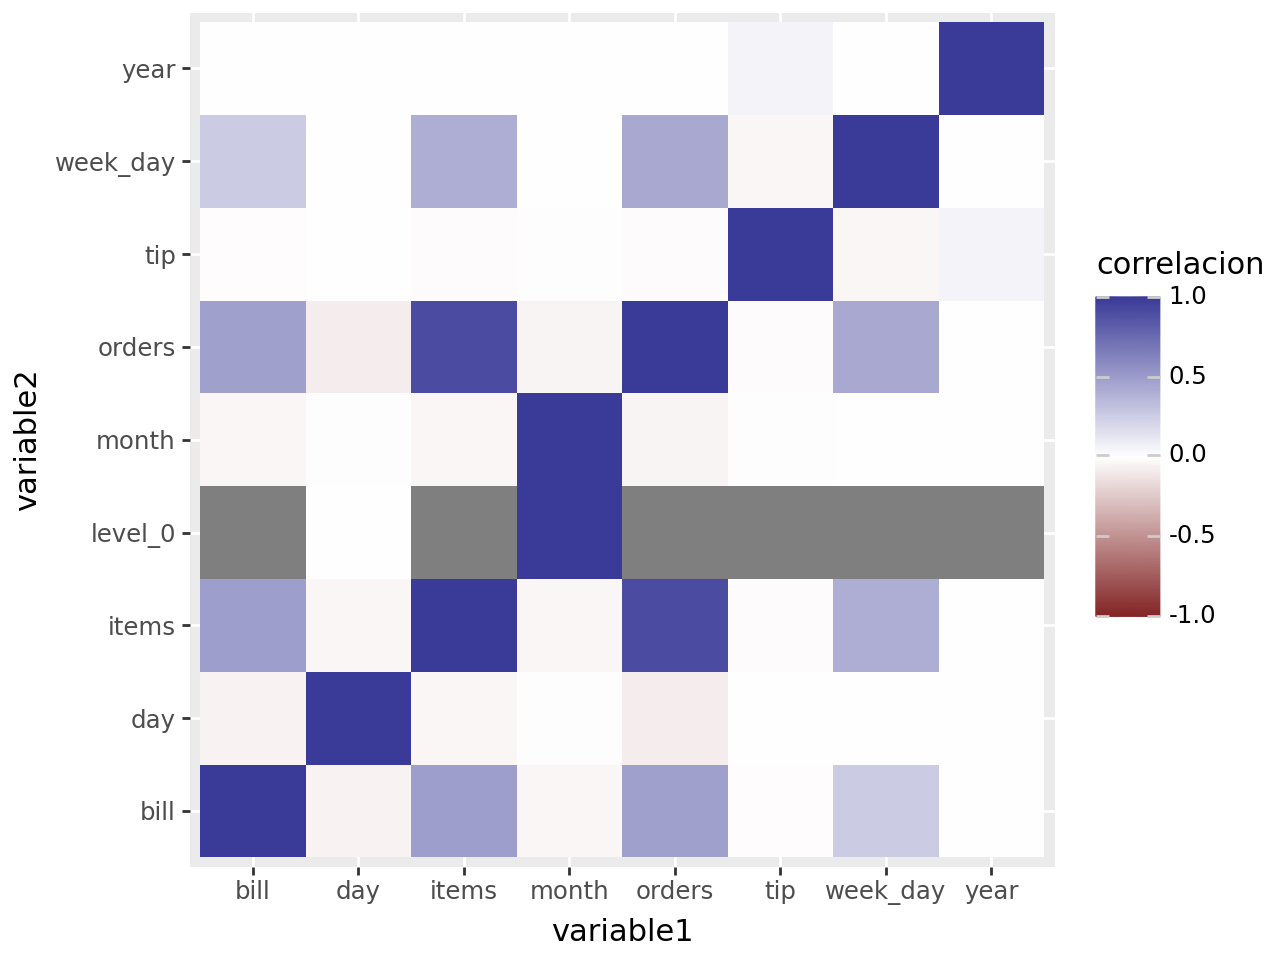

In [31]:
ggplot(aes(x = "variable1", y = "variable2", fill = "correlacion"),correlaciones) +\
geom_tile()+scale_fill_gradient2(limits = [-1,1])

Para finalizar el gráfico, nombraremos los ejes con xlab y ylab, elegiremos un tema con theme y añadiremos los coeficientes de correlación con geom_text().

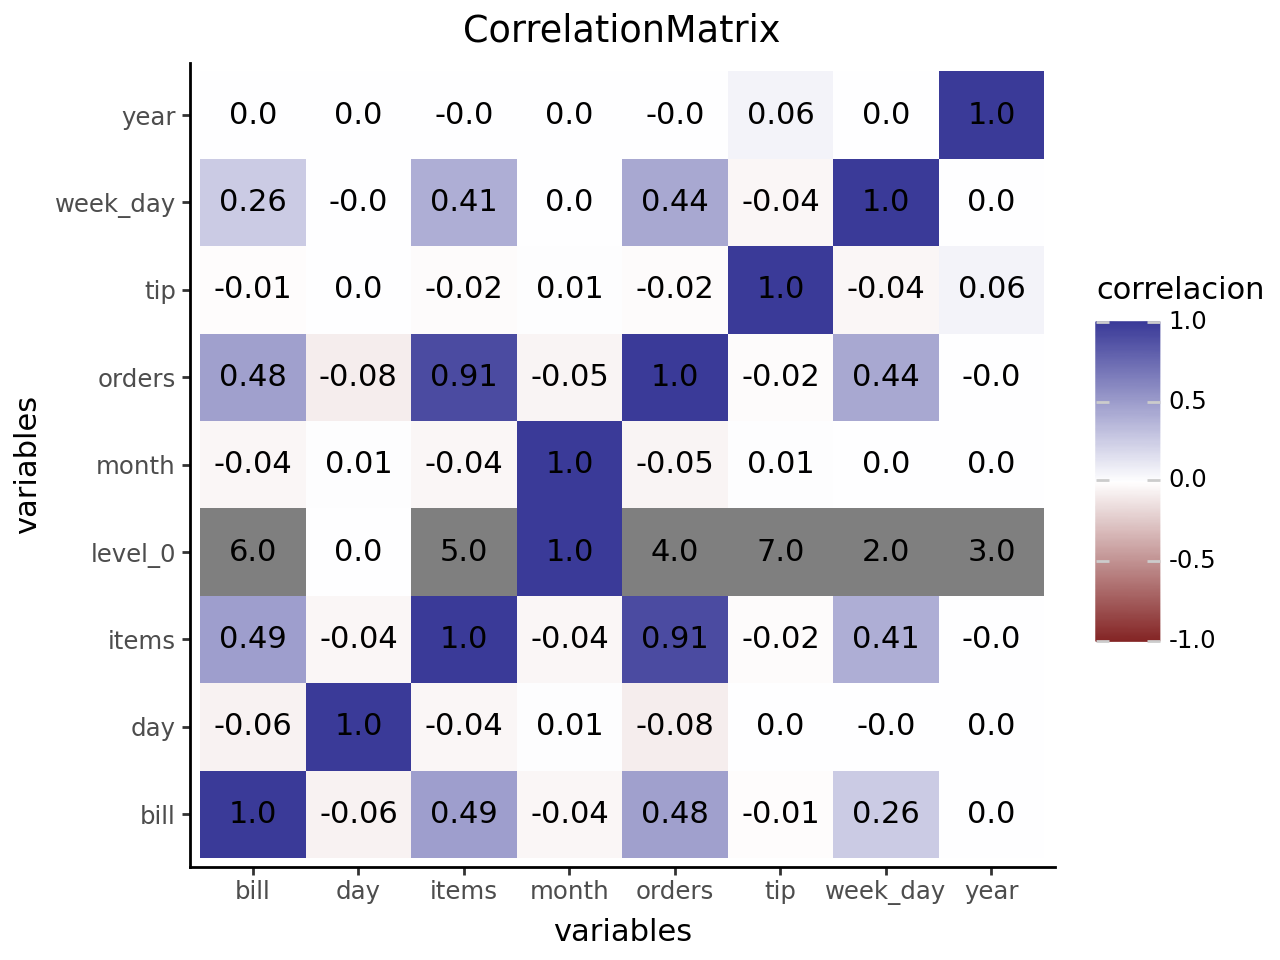

In [33]:
ggplot(aes(x = "variable1", y = "variable2", fill = "correlacion"),correlaciones) +\
geom_tile()+scale_fill_gradient2(limits = [-1,1])+ggtitle("CorrelationMatrix") +\
ylab("variables")+xlab("variables")+theme_classic() +\
geom_text(aes(label="correlacion"))  